# 0. Set up 
Run the following code to install all dependencies and download the APOGEE allStar catalog (this may take a few minutes)

In [1]:
import setup as s
from setup import * 
file_path = './tess_data/'

Installing dependencies...
Done!
Could not import regions, which is required for some of the functionalities of this module.
APOGEE allStar found!


# 1. Observing the Earth 


In this module, we'll be exploring the relationships between exoplanets, their host stars, and the galaxy as a whole. Let's begin by familiarizing ourselves with exoplanets as a concept and how they are studied. 

First, let's imagine that much like ourselves, another form of intelligent life in the Milky Way is trying to determine if they are alone in the Universe. As part of their exoploration, they point their optical telescopes at a number of nearby stars, including our sun. What might they see? 

We can model our sun as a black body of luminosity $L_{\odot} = 3.8 \times 10^{33}~\text{erg s}^{-1}$ and $R_\odot = 7\times 10^{10}$ cm. Let's say these aliens are distance $d$ away. 

## Interactive problem #1 
Use the widgets below to change the distance ($d$) of these aliens from our sun, the transverse velocity our sun appears to travel at with respect to them ($v_t$), and their orbital period around their own host star ($T$).

Explore how these variables affect how our sun appears to them! 

In [ ]:
timels = np.linspace(0, 365*2, 500)
Lsun = 3.8E33 #erg/s

@widgets.interact(d=(0.5, 10, 0.5), R_orbit = (1, 10, 1), v_t=(1E-3, 100, 1E-3), P_orbit = (1, 365, 1))
# x1 is in coordinate units 
# y1 is in coordinate units 
# d is log(parsec) 
# vt is in km/s 
# P_orbit is in days 

def update(d=0.5, R_orbit = 1, v_t = 0.5, P_orbit = 0.25):
    fig, ax = plt.subplots(2,1, figsize=(8, 4), sharex = True)
    [l.remove() for l in ax[0].lines]
    [l.remove() for l in ax[1].lines]
    d_linear = 10**d
    x1 = np.sqrt(d_linear**2/2)
    y1 = x1 
    x,y = s.orbit(R_orbit, P_orbit, timels)
    x_star,y_star = s.target_star(x1,y1,v_t, timels)
    d =  s.distance(x,y,x_star,y_star) 
    solar_flux = s.flux(d, Lsun)
    
    ax[0].plot(timels, np.log10(d), color = 'k')
    ax[1].plot(timels, np.log10(solar_flux)/np.mean(np.log10(solar_flux)), color = 'k')
    ax[0].set_ylabel("Log(Distance) (arbitrary)")
    ax[1].set_xlabel("Time (days)")
    ax[1].set_ylabel("Log(Flux) (arbitrary)")
    #ax[0].set_ylim(0, 2)
    ax[1].set_ylim(0, 2)
    plt.tight_layout()
    plt.subplots_adjust(top = 1.5, hspace = 0.1)

interactive(children=(FloatSlider(value=0.5, description='d', max=10.0, min=0.5, step=0.5), IntSlider(value=1,…

You should see some natural "wiggling" motion as a result of the motion of our observer and that the amplitude of the flux drops off as the distance increases. You can imagine how these two factors make resolving a planet's signature difficult. 

But, let's give it a try anyway! 

## Interactive problem #2 
When a planet passes in front of its host star, we should see a decrease in the observed flux (we can assume the planet's albedo is 0 for simplicity). We refer to the ratio of this decrease in flux $\Delta F$ over the total flux as $D$, the transit depth. 

In [ ]:
@widgets.interact(d=(0.5, 10, 0.5), R_observer = (1, 10, 1), v_t=(1E-3, 100, 1E-3), P_observer = (1, 30, 1),  D_transit = (1E-3, 1,1E-3 ))
def update(d=0.5, R_observer = 1, v_t = 0.5, P_observer = 0.25, D_transit = 0.01):
    fig, ax = plt.subplots(1,1, figsize=(8, 4))
    [l.remove() for l in ax.lines]
    d_linear = 10**d
    x1 = np.sqrt(d_linear**2/2)
    y1 = x1 
    orbit_observer = s.orbit(R_observer, P_observer, timels)
    x_star,y_star = s.target_star(x1, y1, v_t, timels)
    d = s.distance(orbit_observer[0], orbit_observer[1], x_star, y_star)
    fl = s.flux(d, Lsun)
    delta_F = (D_transit)* fl
    flux_transit = fl
    for i, t in enumerate(timels): 
        if(t%365 < 1): 
            flux_transit[i-100:i+100] = fl[i-100:i+100]- (delta_F[i-100:i+100])/d_linear
    ax.plot(timels, flux_transit/np.max(flux_transit), color = 'k')
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel("Flux (arbitrary)")

interactive(children=(FloatSlider(value=0.5, description='d', max=10.0, min=0.5, step=0.5), IntSlider(value=1,…

Now, you should be able to see a "transit" at day 365. That's us! Notice how this transit is <em> much </em> easier to detect when $D$, our transit depth is large. This tells us that there's probably going to be a bias in our telescope's data. If we were to survey hundreds of exoplanets and use the method of detection discussed above, our sample will biased to systems where $D$ is larger. 

## Analytical problem #1 
What effect will our bias toward systems with larger transit depths have on population of exoplanets detected with this method? The distributions of what physical properties, if any, will be affected? 

<b> Answer: </b>


## Analytical problem #2
What other physical properties make detecting exoplanets with the transit method difficult? <b> Hint: </b> What very important quantity is neglecting from the model above? If it were included, what effect would it have?

<b>Answer:</b>

# 2. Ex(o)ploring other worlds

Now that we understand how aliens might find us, let's look at some real data of alien worlds. To do this, we'll be using the Transiting Exoplanet Survey Satellite (TESS). 

<figure>
  <img src="helpful_figures/tess.webp" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <p>An artistic rendition of TESS courtesy of <a href="https://science.nasa.gov/mission/tess/"> NASA </a> 
  </p>
  </div>
</figure>

Launched in 2018 as a successor to the Kepler spacecraft, TESS resides in a high Earth equatorial orbit and surveys neighboring suns by staring at $2300~\text{deg}^2$ of the sky for 27 days at a time. If a planet transit during those 27 days, TESS will observe a dip in its host star's brightness.

The following steps will guide you through the process of detecting a transit using TESS data. 

## Step 1. Download some data 
I've built a function called tess_data_download that takes in the parameters <code>num_obj</code>, <code>order_random</code>, <code>target_index</code>, and <code>search_radius</code>. If no parameters are inputted, light curves for 4680 exoplanets in <a href = "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=TD" > NASA's table of transiting exoplanets </a>. 

The parameters are as follows: 
<p style="text-indent: 50px;">
<code>num_obj</code>: Tells the function to only download a certain number of objects. 
<p style="text-indent: 50px;">
<code>order_random</code>: If set to False (default) the objects will be ordered in sequential order from the table. Otherwise, objects will be randomly selected from the table
<p style="text-indent: 50px;">
<code>target_index</code>: Selects the index of a specific object you want from the table
<p style="text-indent: 50px;">
<code>search_radius</code>: Defaults to 0.1 arcseconds and determines the radius a TESS detection must fall from the planet's radius to be considered a valid match
</p>

Check out <a href='./transiting_exoplanets.csv' > this file </a> and choose your favorite planet.

In [13]:
# to select a target object 
target_obj = "WASP-47 b" # gives a nice lightcurve, but feel free to test some others!
s.tess_data_download(target_name=target_obj)

Target name resolved.
File has already been downloaded


mkdir: tess_data: File exists


Once the download has finished, we can retrieve all the lightcurves we now have for this object: 

In [14]:
target_obj = target_obj.replace(" ", "_")
target_file_path = file_path+target_obj
lightcurve_files = s.glob.glob(s.os.path.join(target_file_path, '*'))

<code> lightcurve_files </code> now contains the locations of all the TESS lightcurves we retrieved for AU Mic b. 

We can look at just one:

Text(0, 0.5, 'Flux (erg/cm$^2$/s)')

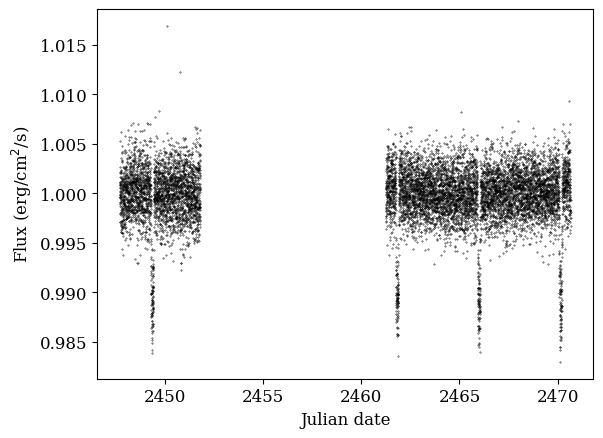

In [15]:
hdu_list = fits.open(lightcurve_files[0], memmap=True)
data = Table(hdu_list[1].data)
# remove data that is flagged as being high quality and data that does not have a value
mask = (data['QUALITY'] == 0) & (~np.isnan(data['PDCSAP_FLUX'])) 
data_filtered = data[mask]
plt.scatter(data['TIME'], data['PDCSAP_FLUX']/np.nanmedian(data['PDCSAP_FLUX']),color = 'k', s= 0.1)
plt.xlabel('Julian date')
plt.ylabel(r'Flux (erg/cm$^2$/s)')

Cool! We can definetly see some variations. But, it's hard to tell which variations are due to the exoplanet and which are due to the motion of the target star relative to us (see Interactive Problem #1 for an example). To highlight the periodic motion we see here and deconvolve any periodicity from the star's motion from the periodicity of an exoplanet's orbit, we can transition this data into frequency-space. However, you'll notice that applying the familiar Fourier transform won't work here. This is because transits do not exhibit sinusoidal shapes, making Fourier transforms an ineffectual method of detecting them. To get around this, we can use the Box Least Squares (BLS) method, which is conceptually similar to a Fourier transform, but models the transit as a "downward box" rather than a sine wave. 

We'll use <code> astropy</code>'s <code>BoxLeastSquares</code> function. You can read more about BLS and its <code>astropy</code> implementation<a href="https://docs.astropy.org/en/stable/timeseries/bls.html" > here</a>.

But, do this, we'll want multiple transits which we can't detect in a single observation unless the orbital period of the planet is less than 13.5 Earth days (TESS typically observes a given star for 27 days). 

Good thing we have multiple observations! Let's merge all of our times, fluxes, and flux errors for each observation into a single list. 

In [16]:
time = []
flux = []
fluxerr = []
for file in lightcurve_files: 
    hdu_list = fits.open(file, memmap=True)
    data = Table(hdu_list[1].data)
    
    #repeat our filtering process 
    mask = (data['QUALITY'] == 0) & (~np.isnan(data['PDCSAP_FLUX']))
    data_filtered = data[mask]
    time = list(data['TIME'])
    flux = list(data['PDCSAP_FLUX'])
    flux_normalized = flux/np.nanmedian(flux)
    fluxerr = list(data['PDCSAP_FLUX_ERR'])
    fluxerr_normalized = fluxerr/np.nanmedian(fluxerr)
    time.extend(time)
    flux.extend(flux_normalized)
    fluxerr.extend(fluxerr_normalized)
# remove any nan values just to be safe
m = np.isnan(flux) | np.isnan(fluxerr)
flux = np.array(flux)[~m]
fluxerr=np.array(fluxerr)[~m]
time = np.array(time)[~m]

Now that we've merged our data, let's apply <code> astropy</code>'s <code>BoxLeastSquares</code> function. As we do this, we'll construct something called a "periodogram" which identifies the underlying frequencies of a signal.

## Step 3. Construct a periodogram

In [17]:
# may take a minute to run depending on how messy the data you selected is. 
# for AU Mic b, it should only take a few seconds.
model = BoxLeastSquares(np.array(time) * u.day, np.array(flux), dy= np.array(fluxerr))
durations = np.linspace(0.1, 0.2, 20) * u.day
results = model.autopower(durations, frequency_factor=5.0)

We can plot our periodogram by doing the following. I've added a bit to the code that will highlight the transit period that algorithm selects and the harmonics.

T = 4.16 days 


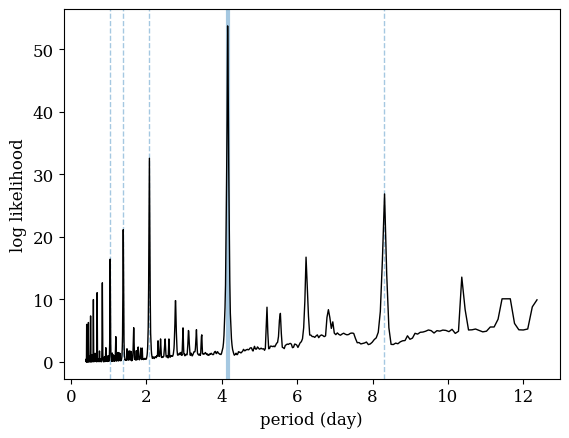

In [18]:
transitperiod = results.period[np.argmax(results.power)]
plt.axvline(transitperiod.value, alpha=0.4, lw=3)
for n in range(2, 5):
    pos_harmonic = n*transitperiod.value
    neg_harmonic= transitperiod.value / n
    if(pos_harmonic <= np.max((results.period).value)): 
        plt.axvline(n*transitperiod.value, alpha=0.4, lw=1, linestyle="dashed")
    if(neg_harmonic >= np.min((results.period).value)):
        plt.axvline(transitperiod.value / n, alpha=0.4, lw=1, linestyle="dashed")
plt.plot(results.period, results.power, color = 'k')
plt.xlabel("period (day)")
plt.ylabel("log likelihood")
print(f"T = {transitperiod.value:.2f} days ")

## Research problem #1
Search up the orbital period of the exoplanet you selected. Is the output of the code consistent with what you find? How does changing the input parameters of the model affect your result?

<b>Answer:</b>

Alongside obtaining our period, we can also obtain the depth of our transit, when in the orbital period the transit occurs, how long the transit takes, etc. 

In [19]:
transitperiod = results.period[np.argmax(results.power)].value
transitdepth = results.depth[np.argmax(results.power)]
transittime = results.transit_time[np.argmax(results.power)].value
transitduration = results.duration[np.argmax(results.power)].value

## Step 4. Your turn! 
Repeat the steps above on any number of exoplanets (use the download function to get more!). Be sure to save the statistics listed above for each planet. 

In [20]:
## YOUR IMPLEMENTATION HERE

# 3. Meeting the host

In section 1, we learned that it's easier to spot an exoplanet with a deeper transit depth. Hopefully, you also noted that since transit depth is proportional to the change in flux that occurs during transit over the star's flux, the host star has a significant role to play. Indeed, not only do the properties of the host star make a given exoplanet more or less detectable, they also influence planet formation. 

We can use the APOGEE catalog we downloaded earlier to get some information on our host(s). 

## Step 1. Read in the APOGEE allStar catalog

In [21]:
# read in APOGEE, this will take a minute 
apogee_allstar = s.fitsio.read('allStar-dr17-synspec_rev1.fits', ext = 1)
# ignore all APOGEE stars that lack RA and/or DEC values 
m = np.isnan(apogee_allstar['RA']) | np.isnan(apogee_allstar['DEC'])
apogee_allstar = apogee_allstar[~m]

## Step 2. Obtain the coordinates of your TESS target(s)

We can get the TESS coordinates of our exoplanet's host star by repeating this command: 

In [22]:
hdu_list = fits.open(lightcurve_files[0], memmap=True)
pl_ra = hdu_list[0].header['RA_OBJ']
pl_dec = hdu_list[0].header['DEC_OBJ']

## Step 3. Find your TESS target(s) in APOGEE

Retrieve the coordinates for as many of our TESS targets as you'd like! Then, we can search for these stars in APOGEE. <b> Hint: </b> If you're looking at multiple TESS targets you may want to make a list of their RA and DEC values to make the following steps faster. 

In [23]:
# search for an apogee match 
apogee_coords = SkyCoord(ra = apogee_allstar['RA']*u.degree, dec = apogee_allstar['DEC']*u.degree, frame = 'icrs')
planet_coords = SkyCoord(ra=pl_ra*u.degree, dec = pl_dec*u.degree, frame = 'icrs')
idx, d2d, d3d = planet_coords.match_to_catalog_sky(apogee_coords)

You'll probably only want to keep the objects for which <code>d2d.arcsec</code> is << 1

## Step 4. Plot your TESS target(s) on a Hertzsprung Russel (HR) diagram

Now, it takes a lot of work to determine the precise age and type of a star, but, using the APOGEE catalog, we can plot our exoplanet's host star on a Hertzsprung Russell (HR) diagram to get a rough idea of our host star.  
<figure>
  <img src="helpful_figures/HRDiagram.png" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <figcaption>An example HR digram from the Hipparcos catalog and Gliese catalog of nearby stars by <a href="https://en.wikipedia.org/wiki/Hertzsprung%E2%80%93Russell_diagram#/media/File:HRDiagram.png" > Richard Powell </a> 
  </figcaption>
</figure>


First, we need to account for how being farther away affects a star's brightness. We can do this using the "distance modulus" $\mu$, which is equal to the apparent magnitude (e.g., the magnitude we see without correcting for distance) minus the absolute magnitude (the distance corrected magnitude). $\mu$ is ALSO equal to $5\log_{10}(d) -5$, a definition that comes from the conventional magnitude scale. We can solve for $M$: 
$$\mu = m - M = 5\log_{10}-5$$
$$M = m - 5\log_{10}-5 $$

The following function computes this: 

In [24]:
def apparent_to_absolute(m,d): 
    return m - 5 - 5*np.log10(d)

Now, let's select <em>only</em> nearby stars so that we don't have to worry about how the dust in the interstellar medium influences our observations. An object that is farther away will also be more heavily influenced by dust. So, by selecting only objects particularly close to us $d < 3$, we can get a pretty good approximation of the HR diagram. If we were doing anything more than an approximation of very local stars, we wouldn't be able to ignore dust like this. But, luckily, TESS targets tend to be local, so its a fair approximation to only look at our solar neighborhood.

We obtain distance from parallax: $$d=\frac{1}{p}$$
Here, distance is given in parasecs and parallax is given in arcseconds.

In [25]:
# if you wish to save computation time, limit your apogee catalog 
apogee_limit = 50000
apogee_limited = apogee_allstar[:apogee_limit]

In [26]:
d = 1/(apogee_limited['GAIAEDR3_PARALLAX']) 
#the 1E3 comes from the fact that Gaia returns parallaxes in units of milliarcseconds

# select only local objects and objects that actually have distance values 
m= (d < 5) & (~np.isnan(d))
d = d[m]

# retrieve the magnitudes in the B, R, and G bands 
Bv = apparent_to_absolute(apogee_limited['GAIAEDR3_PHOT_BP_MEAN_MAG'][m], d)
Rv = apparent_to_absolute(apogee_limited['GAIAEDR3_PHOT_RP_MEAN_MAG'][m],d)
Gv = apparent_to_absolute(apogee_limited['GAIAEDR3_PHOT_G_MEAN_MAG'][m],d)

# get the color by subtracting B and R 
color = Bv-Rv 

/var/folders/2z/y_y_51l51r1cdd9b0xsl_qj80000gn/T/ipykernel_96603/4236576221.py:2: RuntimeWarning: invalid value encountered in log10
  return m - 5 - 5*np.log10(d)


In [27]:
# repeat this process for our exoplanet's host star
d_target = 1/(apogee_allstar['GAIAEDR3_PARALLAX'][idx]) 
Bv_target = apparent_to_absolute(apogee_allstar['GAIAEDR3_PHOT_BP_MEAN_MAG'][idx], d_target)
Rv_target = apparent_to_absolute(apogee_allstar['GAIAEDR3_PHOT_RP_MEAN_MAG'][idx],d_target)
Gv_target = apparent_to_absolute(apogee_allstar['GAIAEDR3_PHOT_G_MEAN_MAG'][idx],d_target)
color_target = Bv_target-Rv_target 

The APOGEE catalog also contains <code>TEFF</code>, which is the effective temperature of each star. We can overplot that quantity as a color since we know stellar temperature varies as stars evolve. 

In [28]:
temp = apogee_limited['TEFF'][m]

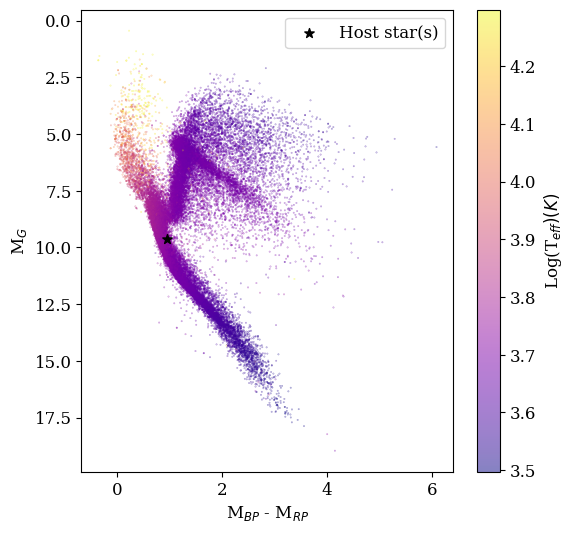

In [29]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(color, Gv, c = np.log10(temp), cmap = 'plasma', s= 0.1, alpha = 0.5)
ax.scatter(color_target, Gv_target, color = 'k', s=50, marker = '*', label = "Host star(s)")
ax.invert_yaxis() 
ax.set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax.set_ylabel(r"M$_{G}$")
plt.colorbar(img, label = r"Log(T$_{eff}) (K)$")
plt.legend(loc="upper right")

## Research problem #2
Where would the sun fall on this plot? Does this make sense? Why or why not? If not, what's wrong with the plot? 

## Research problem #3
What stellar type does your host star(s) appear to correlate with? Does this make sense? Search up your star's spectral type. Were you correct? 


Now, let's get a broader overview of how the exoplanet population looks on this plot. To avoid working through the reduction process hundreds of times, we can cheat a little and just use the data from the <code>transiting_exoplanets.csv</code> file. 

In [30]:
transiting_exo=ascii.read('transiting_exoplanets.csv')

We'll repeat the matching process with APOGEE:

In [31]:
# search for an apogee match 
apogee_coords = SkyCoord(ra = apogee_allstar['RA']*u.degree, dec = apogee_allstar['DEC']*u.degree, frame = 'icrs')
planet_coords = SkyCoord(ra=transiting_exo['ra']*u.degree, dec = transiting_exo['dec']*u.degree, frame = 'icrs')
idx_apogee, d2d, d3d = planet_coords.match_to_catalog_sky(apogee_coords)
m = d2d.arcsec < 0.1 
exoplanet_matches=transiting_exo[m]
apogee_matches = apogee_allstar[idx_apogee[m]]
exoplanet_matches['apogee_idx'] = idx_apogee[m]

And repeat the process of obtaining the absolute magnitudes and colors for our matches. 

In [32]:
d_target = 1/(apogee_matches['GAIAEDR3_PARALLAX']) 
Bv_target = apparent_to_absolute(apogee_matches['GAIAEDR3_PHOT_BP_MEAN_MAG'], d_target)
Rv_target = apparent_to_absolute(apogee_matches['GAIAEDR3_PHOT_RP_MEAN_MAG'],d_target)
Gv_target = apparent_to_absolute(apogee_matches['GAIAEDR3_PHOT_G_MEAN_MAG'],d_target)
color_target = Bv_target-Rv_target 

/var/folders/2z/y_y_51l51r1cdd9b0xsl_qj80000gn/T/ipykernel_96603/4236576221.py:2: RuntimeWarning: invalid value encountered in log10
  return m - 5 - 5*np.log10(d)


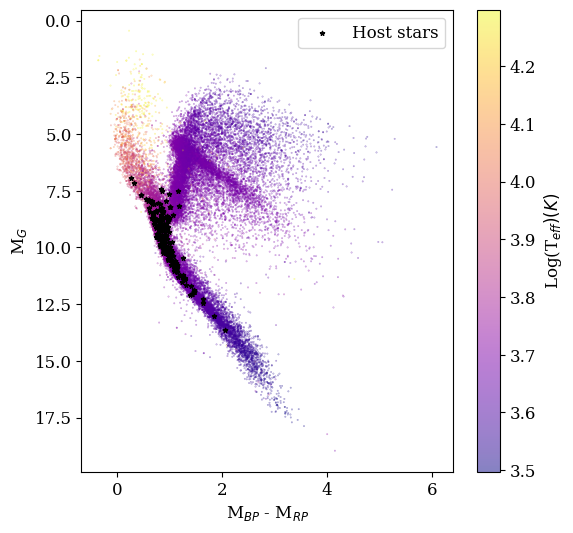

In [33]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(color, Gv, c = np.log10(temp), cmap = 'plasma', s= 0.1, alpha = 0.5)
ax.scatter(color_target, Gv_target, color = 'k', s=10, marker = '*', label = "Host stars")
ax.invert_yaxis() 
ax.set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax.set_ylabel(r"M$_{G}$")
plt.colorbar(img, label = r"Log(T$_{eff}) (K)$")
plt.legend(loc="upper right")

Interesting! You should see that most exoplanets tend to cluster around the F and G spectral classes. 

Let's relate this to some known quantities of exoplanets.

If you look at the <code>transiting_exoplanets.csv</code> file, you'll see a few key quantities. Namely, <code>pl_orbper</code>, <code>pl_trandep</code>, and <code>pl_trandur</code>.

These are three of the quantities we calculated at the end of Section 2!

We can explore what physicial quantities of our exoplanet system we can derive from them. 

First, let's recall our definition for transit depth: $D = \frac{\Delta F}{F_{star}}$

Next, let's define transit duration as the time it takes the exoplanet to complete its transit: $t = \frac{v_{transit}}{D_{star}}$. Here, $D_{star}$ is the diameter of the host star and $v_{transit}$ is the velocity the exoplanet is traveling with during its transit. 

And transit period as the time between transits (e.g., how long a year is on that world).

Since the transit period is conceptually the simplest quantity, let's start there. 

We know $T = \frac{2\pi}{\omega}$ where $\omega = \frac{v}{r}$. Here, $\omega$ is the angular velocity of the exoplanet, $v$ is the linear velocity of the exoplanet, and $r$ is the radius of the exoplanet's orbit. If we assume that we have a circular orbit (not a great assumption, but it simplies a lot), we can determine the radius of the orbit from merely the exoplanet's period and velocity: 
$$\frac{2\pi}{T} = \omega = \frac{v_{transit}}{r_{planet}}$$
$$r_{planet} =\frac{v_{transit}T}{2\pi}$$

We don't know $v_{transit}$, but we can find it from our transit duration! 
$$t = \frac{v_{transit}}{D_{star}}$$
$$v_{transit} = 2tR_{star}$$

Let's assume we can pretty easily find $R_{star}$. 

Now, we can put these quantities together and determine the orbital radius of the exoplanet! 
$$r_{planet} = \frac{2tR_{star}T}{2\pi}$$

Great! But, we haven't used transit depth at all. Let's look at what we can calculating using that. 

The transit depth is the difference between the flux when no transit occurs and when a transit occurs: $D = \frac{F_{star} - F_{transit}}{F_{star}}$. Relating this expression to familiar quantities is a little more complicated. We can begin by stating: $$F_{star} = \frac{L_{star}}{4\pi R_s^2}$$
Then $F_{transit}$ will be the fraction of $L_{star}$ observed over the area of the star that remains uncovered during the planet's transit. We can calculate this area: 
$$A_{uncovered} = A_{star} - A_{planet}$$
$$= 4\pi R_{star}^2 - 4\pi R_{planet}^2$$
$$= 4\pi(R_{star}^2 - R_{planet}^2)$$

This is good! The transit depth is clearly related to the radius of the exoplanet. 

Plugging in for $F_{star}$ and $F_{transit}$...
$$\Delta F = F_{star} - F_{transit} = \frac{L_{star}}{4\pi R_{star}^2}-\frac{L_{star}}{4\pi(R_{star}^2 - R_{planet}^2)}$$
$$= \frac{L_{star}}{4\pi}(\frac{1}{R_{star}^2}) - \frac{1}{(R_{star}^2 - R_{planet}^2)}$$
$$= \frac{L_{star}}{4\pi}(\frac{1}{R_{star}^2}) - \frac{1}{(R_{star}^2 - R_{planet}^2)}$$
$$= \frac{L_{star}}{4\pi} \frac{(R_{star}^2 - R_{planet}^2)}{R_{star}^2(R_{star}^2 - R_{planet}^2)} - \frac{R_{star}^2}{R_{star}^2(R_{star}^2 - R_{planet}^2)}$$
$$= \frac{L_{star}}{4\pi} \frac{(R_{star}^2 - R_{planet}^2) - R_{star}^2}{R_{star}^2(R_{star}^2 - R_{planet}^2)}$$
$$=\frac{L_{star}}{4\pi} \frac{R_{planet}^2}{R_{star}^2(R_{star}^2 - R_{planet}^2)}$$

Now, 
$$D = \frac{\Delta F}{F_{star}}$$
$$D= \frac{\frac{L_{star}}{4\pi} \frac{R_{planet}^2}{R_{star}^2(R_{star}^2 - R_{planet}^2)}}{\frac{L_{star}}{4\pi R_{star}^2}} = \frac{R_{planet}^2}{(R_{star}^2 - R_{planet}^2)}$$
$$D R_{star}^2- D R_{planet}^2 = R_{planet}^2$$
$$D R_{star}^2 = R_{planet}^2(1+D)$$
$$R_{planet}^2 = \frac{D R_{star}^2}{1+D}$$


## Analytical problem #3 
Choose one of the planets you investigated in Section 2 and find its star's radius, the exoplanet's transit period, duration and depth. Use those quantities to derive the planet's orbital radius. Use those quantities to derive the planet's physical radius. 

<b>Answer:</b>

## Interactive problem #3

Complete the following functions based on the derivations shown above. Divide both quantities by the star's radius

In [34]:
def compute_orbitalradius(t, P): 
    ## YOUR CODE HERE 
    return None 
def compute_plradius(D): 
    ## YOUR CODE HERE 
    return None

In [ ]:
rm = exoplanet_matches['st_rad'] != 0 
pl_orbrad = compute_orbitalradius(exoplanet_matches['pl_trandur'][rm], exoplanet_matches['pl_orbper'][rm])
pl_rad = compute_plradius(exoplanet_matches['pl_trandep'][rm])

In [ ]:
fig, ax = plt.subplots(1,2,figsize = (15,10), sharey=True)
ax[0].scatter(color, Gv, color = 'k', s= 1, alpha = 0.5)
ax[1].scatter(color, Gv, color = 'k', s= 1, alpha = 0.5)
img1 = ax[0].scatter(color_target[rm], Gv_target[rm], c = np.log10(pl_orbrad),  cmap = 'plasma', s=40, marker = '*')
img2= ax[1].scatter(color_target[rm], Gv_target[rm], c = np.log10(pl_rad), cmap = 'plasma', s=40, marker = '*')
ax[0].set_ylim(15, 2.5)
ax[0].set_xlim(0, 2.5)
ax[1].set_xlim(0, 2.5)
ax[0].set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax[1].set_xlabel(r"M$_{BP}$ - M$_{RP}$")
ax[0].set_ylabel(r"M$_{G}$")
plt.colorbar(img1, label = r"Log$_{10}$(r$_{orbit}$/R$_*$)", ax = ax[0])
plt.colorbar(img2, label = r"Log$_{10}$(R$_{p}$/R$_{*}$)", ax=ax[1])
plt.tight_layout()

## Research problem #4 

What trends in the data appear? Are these the result of selection or physical effects?

# 4. The big picture

Now that we've seen how stellar hosts influence their exoplanets, let's explore the role of the greater galactic environment. We can understand our galaxy through the following image: 
<figure>
  <img src="helpful_figures/galactic_anatomy.webp" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <p>The anatomy of the Milky Way, courtesy of Kaley Brauer, MIT.</a> 
  </p>
  </div>
</figure>

Currently, many Galactic astronomers are puzzling over the Milky Way's formation. Many speculate that the thin disk was formed more recently as a result of recent gas accretion processes while the thick disk formed earlier, during a rapid and turbulent phase. We expect stars that formed in the early universe (e.g., the thick) to be less metal rich because they would have formed before Type Ia supernovae could enrich the Universe with iron and other metals. Therefore, we expect the thin disk to be metal rich and the thick disk to be metal poor. Since the exoplanets we're looking at fall in our solar neigborhood (< 5 pc), let's explore the distribution of stellar metallicities in this region. Ideally, we should see a lot of higher-metallicity stars as we fall in the thin disk of the galaxy.

In [ ]:
# first, we'll select our solar neighborhood (d < 5 pc)
p = apogee_limited['GAIAEDR3_PARALLAX']
d = 1/p
m = (d < 5)  & (~np.isnan(p))  & p > 0 # include only objects in our solar neighborhood and objects with well-measured parallaxes
neighbor_distance = d[m]
neighbors = apogee_limited[m]

Metallicity can be defined as the ratio of iron to hydrogen ([Fe/H]). However, we don't just want to know if a star is metal rich, we want to know if it contains more metal than it <em> should </em>. So, we'll need to also look at the ratio of an alpha process element (Magnesium, for example) over iron. By investigating the ratio of [Fe/H] to [Mg/Fe], we will be able to quantify if the star is more metal rich than we would otherwise expect based on its [Mg/Fe] ratio. 

Based on the image above, we should expect our local neighborhood to exhibit a higher [Fe/H] ratio than objects that fall outside thet thin disk. We can look at objects in the thick disk by investigating stars at disk height $|z| > $ 5 pc 

In [ ]:
# let's find some objects that fulfill this criteria 
m = np.abs(d) > 5 

not_neighbors = apogee_limited[m]
not_neighbors_distance = d[m]

# convert to galactic coordinates 
coords = SkyCoord(ra = not_neighbors['RA']*u.degree, dec = not_neighbors['DEC']*u.degree, frame = 'icrs')
l = (coords.galactic).l
b = (coords.galactic).b

# retrieve z 
z = not_neighbors_distance*np.sin(l) 


In [ ]:
# make a plot! 

fig, ax = plt.subplots(1,1,figsize = (6,6))
ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 1, label = r'Solar neighborhood ($d$ < 5 pc)', color = 'orange')
ax.scatter(not_neighbors['FE_H'], not_neighbors['MG_FE'], s=1, label = r'$|z|$ > 5 pc', color = 'slateblue')
ax.set_ylim(-1,1)
plt.legend(loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

We can see that our neighborhood is more metal-rich than the high altitude stars we've selected. However, you should see that we still have lots of alpha rich stars in our neighborhood. Why? 

Here's a hint: galaxies are dynamic! It's possible for mixing between the thin and thick disks to occur. A tracer of this should be the motion of the stars. We should see divide in the radial velocities of stars between metal-rich and alpha-rich stars.

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
img = ax.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 1, label = r'Solar neighborhood ($d$ < 5 pc)', c =neighbors['GAIAEDR3_DR2_RADIAL_VELOCITY'], cmap = 'plasma', vmin = -100, vmax = 100)
plt.colorbar(img, ax = ax, label ="RV (km/s)")
ax.set_ylim(-1,1)
plt.legend(loc = 'upper left', fontsize = 11)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')

Indeed, we do! We even get an interesting pocket of stars that stand out in metallicity and radial velocity. But, in general, stars that are less metal rich tend to exhibit higher radial velocities than the stars that fall to the right of the black line (e.g., the metal rich stars). 

Let's explore how a star's membership in the thin disk or thick disk tends to influence the type of exoplanets than form around it. 

Broadly exoplanets can be divided into the following categories: terrestrials, Neptunes, sub-Jupiters, and Jupiters based on their mass and radius. For this project, because we lack information about the planet's mass, we can simplify these categories into: rocky worlds (< 10 $R_{\oplus}$) and gas worlds (> 10 $R_{\oplus}$). 

<figure>
  <img src="helpful_figures/tpr2019-1-mass-radius-diagram.jpg.webp" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <p>A plot of diameter (relative to Earth) versus mass (relative to Earth) for a number of exoplanets. Courtesy of Emily Lakdawalla and Loren A. Roberts. </a> 
  </p>
  </div>
</figure>

In [ ]:
m = pl_orbrad < 10
rocky_worlds = apogee_allstar[exoplanet_matches['apogee_idx'][rm]][m]
gas_worlds = apogee_allstar[exoplanet_matches['apogee_idx'][rm]][~m]

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_axes([0.1, 0.1, 0.6, 0.6]) 
ax2 = fig.add_axes([0.1, 0.73, 0.6, 0.2]) 
ax3 = fig.add_axes([0.73, 0.1, 0.2, 0.6]) 
ax2.get_xaxis().set_visible(False)
ax3.get_yaxis().set_visible(False)


ax1.scatter(neighbors['FE_H'], neighbors['MG_FE'], s= 1, label = r'Solar neighborhood ($d$ < 5 pc)', color = 'k', alpha = 0.5)
ax1.scatter(rocky_worlds['FE_H'], rocky_worlds['MG_FE'], marker = 'o', facecolor = 'None', edgecolor = 'blue', s=20, linewidth = 1, label = r"Rocky worlds (R < 5R$_{\oplus}$)")
ax1.scatter(gas_worlds['FE_H'], gas_worlds['MG_FE'], marker = 'o', facecolor = 'None', edgecolor = 'darkorange', s=50, linewidth = 2, label = r"Gas worlds (R > 5$R_{\oplus}$)")
ax1.set_xlabel("[Fe/H]")
ax1.set_ylabel("[Mg/Fe]")
ax1.set_ylim(-1,1)
ax1.set_xlim(-2,0.75)

ax2.hist(neighbors['FE_H'], color = 'k', histtype = 'step', bins = 10)
ax2.hist(rocky_worlds['FE_H'], color = 'blue', histtype = 'step', bins = 10)
ax2.hist(gas_worlds['FE_H'], color = 'darkorange', histtype = 'step', bins = 10)
ax2.set_yscale('log')
ax2.set_xlim(-2,0.75)

ax3.hist(neighbors['MG_FE'], color = 'k', histtype = 'step', orientation = 'horizontal', bins = 10)
ax3.hist(rocky_worlds['MG_FE'], color = 'blue', histtype = 'step', orientation = 'horizontal', bins = 10)
ax3.hist(gas_worlds['MG_FE'], color = 'darkorange', histtype = 'step', orientation = 'horizontal', bins = 10)
ax3.set_xscale('log')
ax3.set_ylim(-1,1)

## Research problem #5
What trends in the data do you see? What do these trends imply about how galaxies influence (or don't influence) exoplanet formation? 